In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import warnings
import glob
warnings.filterwarnings('ignore')
from jupyterthemes import jtplot
jtplot.style()
from sklearn import metrics

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import random

def pyRandColor():
    randNums = [random.random() for _ in range(0, 3)]

    RGB255 = list([ int(i * 255) for i in randNums ])
    RGB1 = list([ round(i, 2) for i in randNums ])
    return RGB1


## Data

In [2]:
def getData(filepath, varname='human', cols=['perplexity', 'percentage', 'entropy_rate', 'rates']):
    """
    Load and process a CSV file where the 'rates' column contains stringified lists.

    This follows paper_results003 exactly for rate availability:
    rows with missing rates are dropped; existing rates are read from the CSV
    and expanded into rates_0, rates_1, ... columns.
    """
    import pandas as pd
    import ast

    df = pd.read_csv(filepath)[cols]
    df = df.dropna(subset=["rates"])
    df['rates'] = df['rates'].apply(ast.literal_eval)

    rates_df = df['rates'].apply(pd.Series)
    rates_df.columns = [f'rates_{i}' for i in rates_df.columns]

    df_expanded = pd.concat([df.drop(columns=['rates']), rates_df], axis=1)

    return df_expanded.assign(label=varname)


## Recognition without training using averged estimate of entropy rate

In [3]:
from pathlib import Path

# Resolve the repository root whether this notebook is run from repo root
# or from the notebooks/ directory.
_CWD = Path.cwd().resolve()
if _CWD.joinpath('api_data_collection').exists():
    REPO_PATH = _CWD
elif _CWD.parent.joinpath('api_data_collection').exists():
    REPO_PATH = _CWD.parent
else:
    raise RuntimeError(
        "Could not locate the nero repository root. Run this notebook from "
        "the repository root or notebooks/ directory."
    )

LEGACY = REPO_PATH / 'paper_data' / 'legacy'
API = REPO_PATH / 'api_data_collection' / 'ai_data'

# Legacy datasets retained from paper_results002.
human1=getData(LEGACY/'gutenberg/gutenberg_table.csv',varname=0)
human2=getData(LEGACY/'arxiv_entropy/arxiv_table.csv',varname=0)
ai1=getData(LEGACY/'ai_longform_gpt4o/ai_web_longform_table.csv',varname=1)
ai2=getData(LEGACY/'ai_longform_gpt3.5/gpt_35_table.csv',varname=1)
ai3=getData(LEGACY/'ai_longform_gpt4.0/gpt_40_table.csv',varname=1)

# API-data tables used by paper_results003.
# As in notebook 003, rates are read directly from each detection CSV.
# Rows with rates == NaN are dropped by getData(); no NERO regeneration occurs.
human3=getData(API/'loc-pd/loc-pd_detection.csv',varname=0)
human4=getData(API/'us-pd/us-pd_detection.csv',varname=0)
ai0=getData(API/'openai/gpt4o/gpt_4o_detection.csv',varname=1)
ai4=getData(API/'claude_sonnet_4/claude_detection.csv',varname=1)
ai5=getData(API/'gemini_2.5_pro/gemini_25_detection.csv',varname=1)
ai6=getData(API/'openai/gpt5/gpt_5_detection.csv',varname=1)
ai7=getData(API/'openai/gpt4.0/gpt_4zero_detection.csv',varname=1)

dallhuman=pd.concat([human1,human2,human3,human4])

df=pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai6,ai7])

NAMES={'human1':'Gutenberg project (legacy 002)',
       'human2':'Arxiv papers (legacy 002)',
       'human3':'Library of Congress public domain (003)',
       'human4':'US public domain (003)',
       'ai0':'API GPT-4o (003)',
       'ai1':'AI Generated GPT-4o longform (legacy 002)',
       'ai2':'AI Generated GPT-3.5 longform (legacy 002)',
       'ai3':'AI Generated GPT-4.0 longform (legacy 002)',
       'ai4':'Claude Sonnet 4 (003)',
       'ai5':'Gemini 2.5 Pro (003)',
       'ai6':'GPT-5 (003)',
       'ai7':'API GPT-4.0 (003)',
      }

print('repo:', REPO_PATH)
print('rows after dropping missing rates:', {name: len(globals()[name]) for name in NAMES})


repo: /home/runner/work/nero/nero
rows after dropping missing rates: {'human1': 406, 'human2': 42, 'human3': 77, 'human4': 93, 'ai0': 282, 'ai1': 98, 'ai2': 100, 'ai3': 41, 'ai4': 980, 'ai5': 1036, 'ai6': 204, 'ai7': 50}


In [4]:
#dh=df.copy()
df_=df.copy()
df_['nz_entropy_rate']=df[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df.apply(func1,axis=1)
#df=df.drop('nzero',axis=1)

In [5]:
ytrue=df_.label.values


ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.8303574016806214
0.7192449377854617
0.5608088991545873
px 0.7294876388391256
%-> 0.940855894872446


In [6]:
pd.DataFrame(ytrue).to_csv('ytrue.csv')


In [7]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.1,
    interpolate=True,
    convexify=True)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)

(0.8373555967408287,
 np.float64(0.8516376673777698),
 np.float64(0.8230735261038876))

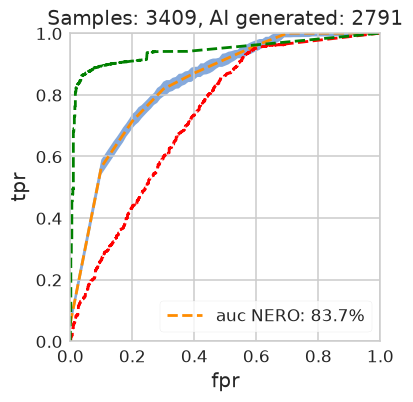

In [8]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
#ax=ztz.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)

#plt.fill_between(x=ztz.get().index, y1=ztz.df_lim['U'].tpr,y2=ztz.df_lim['L'].tpr, alpha=.6)
DP.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='red',lw=2)
DPc.sort_values('tpr').set_index('fpr').tpr.plot(style='--',ax=ax,color='green',lw=2)

#DP.to_csv('perplexity_all.csv')
#DPc.to_csv('percentage_all.csv')

ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining1.pdf',bbox_inches='tight',transparent=True)

In [9]:
#dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
#dx.to_csv('nero_all_notraining.csv')

In [10]:
from sklearn import metrics
df_all=pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai6,ai7])
SUBSET='ALL'

In [11]:
#dh=df.copy()
df_=df_all.copy()
df_['nz_entropy_rate']=df_[[x for x in df_.columns if 'rates' in x]].replace(0,None).median(axis=1)

def func1(row):
    n=0
    for i in row.values:
        if i == 0:
            n=n+1
    return n
nz=(df_!=0).iloc[:,3:43].mean(axis=1)
nzstd=(df_!=0).iloc[:,3:43].std(axis=1)
df_['nzmean'] = nz
df_['nzstd'] = nzstd
df_['nzero'] = df_.apply(func1,axis=1)

In [12]:
ytrue=df_.label.values
ypred= df_.fillna(0).nz_entropy_rate.values #+ df.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr, tpr, thresholds = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e=auc(fpr, tpr)
print('nzent',auc_e)
D1=pd.DataFrame({'fpr':fpr,'tpr':tpr,'threshold':thresholds}).set_index('threshold').sort_index().dropna()
#D1.to_csv('./src/neroroce.csv')

ypred=  df_.fillna(0).entropy_rate.values
#y_pred=np.median(X,axis=1)
fpr2, tpr2, thresholds2 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e2=auc(fpr2, tpr2)
print(auc_e2)
D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2]).to_csv('neroroce_frac.csv')


ypred=  df_.fillna(0).nzero.values
#y_pred=np.median(X,axis=1)
fpr3, tpr3, thresholds3 = metrics.roc_curve(ytrue,ypred, pos_label=0)
auc_e3=auc(fpr3, tpr3)
print(auc_e3)
D3=pd.DataFrame({'fpr':fpr3,'tpr':tpr3,'threshold':thresholds3}).set_index('threshold').sort_index().dropna()#.to_csv('./src/neroroce.csv')
pd.concat([D1,D2,D3]).to_csv('neroroce_frac.csv')



ypred=  df_.fillna(0).perplexity.values
#y_pred=np.median(X,axis=1)
fprP, tprP, thresholdsP = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_P=auc(fprP, tprP)
print('px',auc_P)
DP=pd.DataFrame({'fpr':fprP,'tpr':tprP,'threshold':thresholdsP}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')
DP.to_csv('perplexity_frac.csv')


ypred=  df_.fillna(0).percentage.values
#y_pred=np.median(X,axis=1)
fprPc, tprPc, thresholdsPc = metrics.roc_curve(ytrue,ypred, pos_label=1)
auc_Pc=auc(fprPc, tprPc)
print('%->',auc_Pc)
DPc=pd.DataFrame({'fpr':fprPc,'tpr':tprPc,'threshold':thresholdsPc}).set_index('threshold').sort_index().dropna()#.to_csv('./src/perplexity.csv')
DPc = DPc[~np.isinf(DPc.index)]
DPc.to_csv('percentage_frac.csv')
#D2=pd.DataFrame({'fpr':fpr2,'tpr':tpr2,'threshold':thresholds2}).set_index('threshold').sort_index().dropna()
#pd.concat([D1,D2,DP]).to_csv('./src/neroroce.csv')


nzent 0.8303574016806214
0.7192449377854617
0.5742368268788142
px 0.7294876388391256
%-> 0.940855894872446


In [13]:
from zedstat import zedstat 
zte=zedstat.processRoc(df=pd.read_csv('neroroce_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

zte.smooth(STEP=0.001)
zte.allmeasures(interpolate=True)
zte.usample(precision=2)
zte.getBounds()

auc_e=np.array(zte.auc(alpha=.05))*100
deltae=(auc_e[1]-auc_e[2])/2
le=str(auc_e[0])[:4]+'%'
zte.auc(alpha=.05)


ztpc=zedstat.processRoc(df=pd.read_csv('percentage_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpc.smooth(STEP=0.001)
ztpc.allmeasures(interpolate=True)
ztpc.usample(precision=2)
ztpc.getBounds()

auc_pc=np.array(ztpc.auc(alpha=.05))*100
deltapc=(auc_pc[1]-auc_pc[2])/2
lpc=str(auc_pc[0])[:4]+'%'
ztpc.auc(alpha=.05)



ztpx=zedstat.processRoc(df=pd.read_csv('perplexity_frac.csv'),
           order=3, 
           total_samples=len(ytrue),
           positive_samples=ytrue.sum(),
           alpha=0.01,
           prevalence=.5)

ztpx.smooth(STEP=0.001)
ztpx.allmeasures(interpolate=True)
ztpx.usample(precision=2)
ztpx.getBounds()

auc_px=np.array(ztpx.auc(alpha=.05))*100
deltapx=(auc_px[1]-auc_px[2])/2
lpx=str(auc_px[0])[:4]+'%'
ztpx.auc(alpha=.05)

(0.7344553978040609,
 np.float64(0.7536439605025134),
 np.float64(0.7152668351056084))

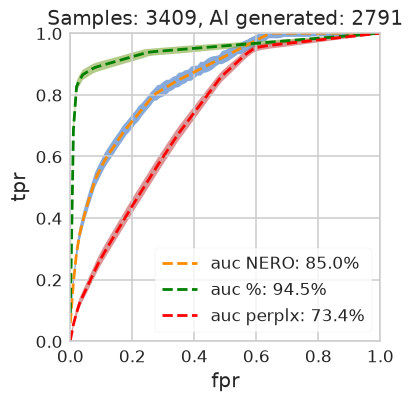

In [14]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO: '+le,'auc %: '+lpc,'auc perplx: '+lpx],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)

# AUC distribution for subsets

In [15]:
import itertools
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import auc as sk_auc
from zedstat import zedstat
from tqdm import tqdm

def _roc_df_from_scores(ytrue, yscore, *, pos_label):
    fpr, tpr, thr = metrics.roc_curve(ytrue, yscore, pos_label=pos_label)
    df = pd.DataFrame({"threshold": thr, "fpr": fpr, "tpr": tpr}).dropna()
    # Keep finite only
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


def _dedupe_by_fpr_keep_max_tpr(df: pd.DataFrame) -> pd.DataFrame:
    # zedstat later indexes by fpr; ensure enough unique fpr points
    df = df.sort_values("fpr")
    df = df.groupby("fpr", as_index=False)["tpr"].max()
    return df.sort_values("fpr")


def _zedstat_auc_from_roc_df(
    roc_df: pd.DataFrame,
    *,
    total_samples: int,
    positive_samples: int,
    prevalence: float,
    alpha_process: float,
    alpha_auc: float,
    smooth_step: float,
    order: int,
):
    """
    Returns (auc_percent, used_order, method_str).
    Falls back to sklearn AUC if zedstat spline bounds are impossible.
    """
    roc_df = roc_df[["fpr", "tpr"]].copy()
    roc_df = _dedupe_by_fpr_keep_max_tpr(roc_df)

    n_unique = roc_df["fpr"].nunique()
    if n_unique < 2:
        # Not even a curve
        return float("nan"), None, "nan"

    # pick a safe spline order for zedstat's spline interpolation
    safe_order = min(order, n_unique - 1)
    if safe_order < 1:
        # linear AUC directly
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), 1, "sklearn"

    try:
        zt = zedstat.processRoc(
            df=roc_df,
            order=safe_order,
            total_samples=total_samples,
            positive_samples=positive_samples,
            alpha=alpha_process,
            prevalence=prevalence,
        )
        zt.smooth(STEP=smooth_step)
        zt.allmeasures(interpolate=True)
        zt.usample(precision=2)
        zt.getBounds()
        auc_val = float(np.array(zt.auc(alpha=alpha_auc))[0] * 100.0)
        return auc_val, safe_order, "zedstat"
    except Exception:
        # final fallback: compute AUC directly from the deduped ROC
        return float(sk_auc(roc_df["fpr"].values, roc_df["tpr"].values) * 100.0), safe_order, "sklearn"


def compute_auc_triple_for_df(
    df_gpt5: pd.DataFrame,
    *,
    label_col: str = "label",
    entropy_rate_col: str = "entropy_rate",
    perplexity_col: str = "perplexity",
    percentage_col: str = "percentage",
    rates_col_substring: str = "rates",
    nz_slice: tuple[int, int] = (3, 43),
    prevalence: float = 0.5,
    alpha_process: float = 0.01,
    alpha_auc: float = 0.05,
    smooth_step: float = 0.001,
    order: int = 3,
    require_both_classes: bool = True,
):
    df_ = df_gpt5.copy()

    if label_col not in df_.columns:
        raise ValueError(f"Missing label column: '{label_col}'")

    ytrue = df_[label_col].values

    if require_both_classes and len(np.unique(ytrue)) < 2:
        # cannot define ROC/AUC
        return (np.nan, np.nan, np.nan)

    # nz_entropy_rate
    rate_cols = [c for c in df_.columns if rates_col_substring in c]
    if not rate_cols:
        raise ValueError(f"No columns found containing substring '{rates_col_substring}'")
    df_["nz_entropy_rate"] = df_[rate_cols].replace(0, None).median(axis=1)

    # nzero across row (as in your code)
    def func1(row):
        n = 0
        for i in row.values:
            if i == 0:
                n += 1
        return n

    lo, hi = nz_slice
    df_["nzmean"] = (df_ != 0).iloc[:, lo:hi].mean(axis=1)
    df_["nzstd"] = (df_ != 0).iloc[:, lo:hi].std(axis=1)
    df_["nzero"] = df_.apply(func1, axis=1)

    total_samples = len(ytrue)
    positive_samples = int(np.sum(ytrue))

    # --- “neroroce” composite: D1 + D2 + D3 (all with pos_label=0) ---
    roc1 = _roc_df_from_scores(ytrue, df_.fillna(0)["nz_entropy_rate"].values, pos_label=0)
    roc2 = _roc_df_from_scores(ytrue, df_.fillna(0)[entropy_rate_col].values, pos_label=0)
    roc3 = _roc_df_from_scores(ytrue, df_.fillna(0)["nzero"].values, pos_label=0)

    neroroce = pd.concat([roc1[["fpr", "tpr"]], roc2[["fpr", "tpr"]], roc3[["fpr", "tpr"]]], axis=0)
    auc_e, _, _ = _zedstat_auc_from_roc_df(
        neroroce,
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- percentage (pos_label=1) ---
    roc_pc = _roc_df_from_scores(ytrue, df_.fillna(0)[percentage_col].values, pos_label=1)
    auc_pc, _, _ = _zedstat_auc_from_roc_df(
        roc_pc[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    # --- perplexity (pos_label=1) ---
    roc_px = _roc_df_from_scores(ytrue, df_.fillna(0)[perplexity_col].values, pos_label=1)
    auc_px, _, _ = _zedstat_auc_from_roc_df(
        roc_px[["fpr", "tpr"]],
        total_samples=total_samples,
        positive_samples=positive_samples,
        prevalence=prevalence,
        alpha_process=alpha_process,
        alpha_auc=alpha_auc,
        smooth_step=smooth_step,
        order=order,
    )

    return auc_e, auc_pc, auc_px


def auc_triples_over_subsets(
    dfs: dict[str, pd.DataFrame],
    *,
    human_keys=("human1", "human2", "human3", "human4"),
    ai_keys=("ai0", "ai1", "ai2", "ai3", "ai4", "ai5", "ai6", "ai7"),
    min_humans=1,
    min_ais=1,
    human_subset_sizes=(1,),
    ai_subset_sizes=(1,),
    drop_nan_triples=True,
    **auc_kwargs,
) -> pd.DataFrame:
    missing = [k for k in (*human_keys, *ai_keys) if k not in dfs]
    if missing:
        raise KeyError(f"Missing dfs entries for: {missing}")

    rows = []
    for hs in human_subset_sizes:
        for humans_sel in itertools.combinations(human_keys, hs):
            for asz in tqdm(ai_subset_sizes):
                for ais_sel in itertools.combinations(ai_keys, asz):
                    if len(humans_sel) < min_humans or len(ais_sel) < min_ais:
                        continue
                    chosen = list(humans_sel) + list(ais_sel)
                    df_cat = pd.concat([dfs[k] for k in chosen], axis=0, ignore_index=True)

                    a1, a2, a3 = compute_auc_triple_for_df(df_cat, **auc_kwargs)

                    if drop_nan_triples and (np.isnan(a1) or np.isnan(a2) or np.isnan(a3)):
                        continue

                    rows.append(
                        {
                            "humans": tuple(humans_sel),
                            "ais": tuple(ais_sel),
                            "n_humans": len(humans_sel),
                            "n_ais": len(ais_sel),
                            "auc_neroroc": a1,
                            "auc_percentage": a2,
                            "auc_perplexity": a3,
                            "auc_mean": np.nanmean([a1, a2, a3]),
                        }
                    )

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("auc_mean", ascending=False)
    return out

In [16]:
%%time
dfs = {
    "human1": human1, "human2": human2, "human3": human3, "human4": human4,
    "ai0": ai0, "ai1": ai1, "ai2": ai2, "ai3": ai3,
    "ai4": ai4, "ai5": ai5, "ai6": ai6, "ai7": ai7,
}

res = auc_triples_over_subsets(
    dfs,
    human_subset_sizes=tuple(range(1, 5)),
    ai_subset_sizes=tuple(range(1, 9))
)

  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:01<00:08,  1.22s/it]

 25%|██▌       | 2/8 [00:05<00:18,  3.11s/it]

 38%|███▊      | 3/8 [00:14<00:29,  5.92s/it]

 50%|█████     | 4/8 [00:27<00:33,  8.44s/it]

...

 75%|███████▌  | 6/8 [00:41<00:15,  7.54s/it]

 88%|████████▊ | 7/8 [00:43<00:05,  5.56s/it]

100%|██████████| 8/8 [00:43<00:00,  3.85s/it]

100%|██████████| 8/8 [00:43<00:00,  5.43s/it]

CPU times: user 10min 36s, sys: 3.81 s, total: 10min 39s
Wall time: 10min 39s


In [17]:
import numpy as np
from scipy import stats

alpha=0.01
pct=int(np.round(100*(1-alpha),0))
def mean_ci(x, alpha=alpha):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan

    mu = x.mean()
    s = x.std(ddof=1)
    se = s / np.sqrt(n)

    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lo = mu - tcrit * se
    hi = mu + tcrit * se
    return mu, lo, hi


m_e, lo_e, hi_e   = mean_ci(res.auc_neroroc)
m_px, lo_px, hi_px = mean_ci(res.auc_perplexity)
m_pc, lo_pc, hi_pc = mean_ci(res.auc_percentage)

print(f"NeuroROC AUC   : {m_e:.3f}  ({pct}% CI [{lo_e:.3f}, {hi_e:.3f}])")
print(f"Perplexity AUC : {m_px:.3f}  ({pct}% CI [{lo_px:.3f}, {hi_px:.3f}])")
print(f"Percentage AUC : {m_pc:.3f}  ({pct}% CI [{lo_pc:.3f}, {hi_pc:.3f}])")


NeuroROC AUC   : 88.180  (99% CI [87.975, 88.386])
Perplexity AUC : 82.479  (99% CI [81.866, 83.093])
Percentage AUC : 93.449  (99% CI [93.171, 93.726])


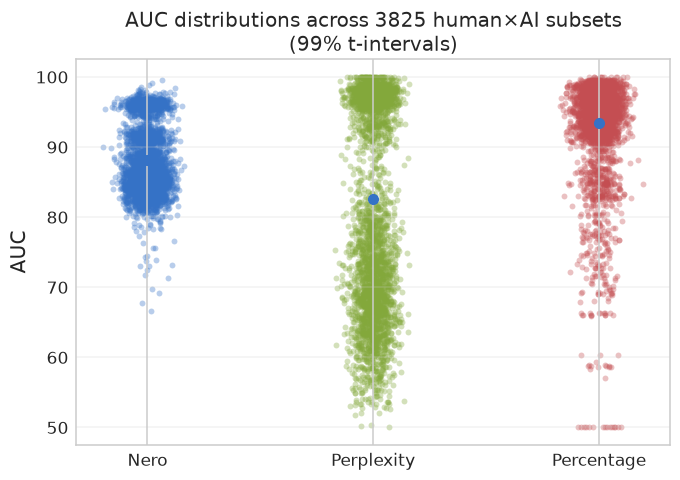

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Collect data
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

means, los, his = [], [], []
for x in data:
    m, lo, hi = mean_ci(x)
    means.append(m)
    los.append(lo)
    his.append(hi)

xpos = np.arange(len(labels))

plt.figure(figsize=(7,5))

# Scatter points with jitter
rng = np.random.default_rng(0)
for i, x in enumerate(data):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    plt.scatter(
        np.full_like(x, xpos[i]) + jitter,
        x,
        alpha=0.35,
        s=18,
        linewidths=0
    )

# Error bars (mean ± CI)
yerr = np.vstack([
    np.array(means) - np.array(los),
    np.array(his) - np.array(means)
])

plt.errorbar(
    xpos,
    means,
    yerr=yerr,
    fmt='o',
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=10
)

plt.xticks(xpos, labels)
plt.ylabel("AUC")
plt.title(f"AUC distributions across {len(res)} human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


In [19]:
res

,humans,ais,n_humans,n_ais,auc_neroroc,auc_percentage,auc_perplexity,auc_mean
766,"(human4,)","(ai1,)",1,1,98.740182,99.489796,100.000000,99.409993
784,"(human4,)","(ai1, ai6)",1,2,97.767086,98.675497,100.000000,98.814194
771,"(human4,)","(ai6,)",1,1,97.689611,98.284314,100.000000,98.657975
2296,"(human3, human4)","(ai1,)",2,1,95.316961,99.489796,100.000000,98.268919
783,"(human4,)","(ai1, ai5)",1,2,96.932778,99.955908,97.883598,98.257428
...,...,...,...,...,...,...,...,...
1045,"(human1, human2)","(ai2, ai7)",2,2,84.023810,65.951970,72.154852,74.043544
75,"(human1,)","(ai2, ai3, ai7)",1,3,81.023987,68.949005,71.793496,73.922163
7,"(human1,)","(ai7,)",1,1,73.162562,98.522630,50.000000,73.895064
25,"(human1,)","(ai2, ai7)",1,2,82.995895,65.928553,69.905205,72.943217


In [20]:
import numpy as np
import pandas as pd

# ---- 1) scatter points (jittered) dataframe ----
labels = ["Nero", "Perplexity", "Percentage"]
data = [
    np.asarray(res.auc_neroroc, dtype=float),
    np.asarray(res.auc_perplexity, dtype=float),
    np.asarray(res.auc_percentage, dtype=float),
]

rng = np.random.default_rng(0)

rows = []
for i, (lab, x) in enumerate(zip(labels, data)):
    x = x[~np.isnan(x)]
    jitter = rng.normal(0, 0.05, size=len(x))
    for y, j in zip(x, jitter):
        rows.append(
            {
                "metric": lab,
                "x_center": i,          # integer category position
                "x_jitter": float(j),   # jitter added
                "x": float(i + j),      # final x used in scatter
                "auc": float(y),
            }
        )

df_scatter = pd.DataFrame(rows)
df_scatter.to_csv("auc_scatter_pgf.csv", index=False)

# ---- 2) summary (mean + CI) dataframe ----
summ_rows = []
for i, lab in enumerate(labels):
    mu, lo, hi = mean_ci(df_scatter.loc[df_scatter.metric == lab, "auc"].values)
    summ_rows.append(
        {
            "metric": lab,
            "x": i,
            "mean": float(mu),
            "ci_lo": float(lo),
            "ci_hi": float(hi),
            "err_lo": float(mu - lo),   # for pgfplots y error bars if desired
            "err_hi": float(hi - mu),
            "alpha": float(alpha),
            "pct": int(pct),
            "n": int(df_scatter.loc[df_scatter.metric == lab, "auc"].shape[0]),
        }
    )

df_summary = pd.DataFrame(summ_rows)
df_summary.to_csv("auc_summary_pgf.csv", index=False)

print("Wrote:", "auc_scatter_pgf.csv", "auc_summary_pgf.csv")
display(df_summary)
display(df_scatter)


Wrote: auc_scatter_pgf.csv auc_summary_pgf.csv


,metric,x,mean,ci_lo,ci_hi,err_lo,err_hi,alpha,pct,n
0,Nero,0,88.180047,87.974577,88.385516,0.205470,0.205470,0.01,99,3825
1,Perplexity,1,82.479402,81.865729,83.093074,0.613672,0.613672,0.01,99,3825
2,Percentage,2,93.448585,93.170898,93.726272,0.277687,0.277687,0.01,99,3825


,metric,x_center,x_jitter,x,auc
0,Nero,0,0.006287,0.006287,98.740182
1,Nero,0,-0.006605,-0.006605,97.767086
2,Nero,0,0.032021,0.032021,97.689611
3,Nero,0,0.005245,0.005245,95.316961
4,Nero,0,-0.026783,-0.026783,96.932778
...,...,...,...,...,...
11470,Percentage,2,-0.032965,1.967035,65.951970
11471,Percentage,2,-0.002394,1.997606,68.949005
11472,Percentage,2,-0.026231,1.973769,98.522630
11473,Percentage,2,-0.033943,1.966057,65.928553


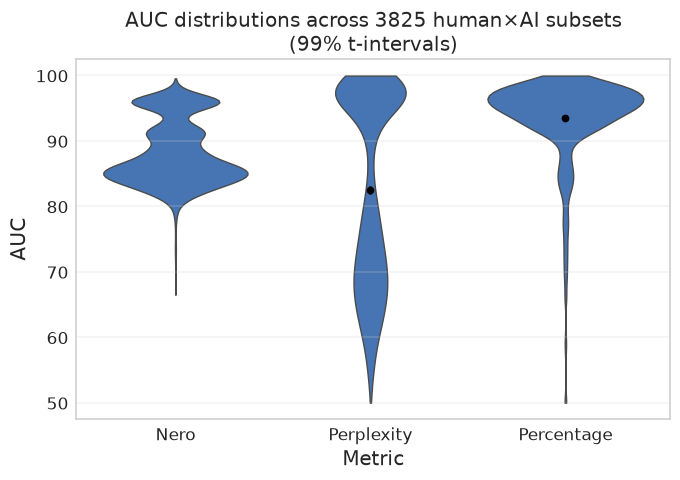

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare long-form dataframe
df_plot = pd.DataFrame({
    "AUC": np.concatenate([
        np.asarray(res.auc_neroroc, dtype=float),
        np.asarray(res.auc_perplexity, dtype=float),
        np.asarray(res.auc_percentage, dtype=float),
    ]),
    "Metric": (
        ["Nero"] * len(res.auc_neroroc)
        + ["Perplexity"] * len(res.auc_perplexity)
        + ["Percentage"] * len(res.auc_percentage)
    )
}).dropna()

plt.figure(figsize=(7,5))

sns.violinplot(
    data=df_plot,
    x="Metric",
    y="AUC",
    inner=None,          # no quartile bars
    cut=0,               # don't extend beyond data
    linewidth=1
)

# Overlay mean + CI
metrics = ["NeuroROC", "Perplexity", "Percentage"]
for i, m in enumerate(metrics):
    vals = df_plot.loc[df_plot.Metric == m, "AUC"].values
    mu, lo, hi = mean_ci(vals)
    plt.errorbar(
        i,
        mu,
        yerr=[[mu - lo], [hi - mu]],
        fmt="o",
        color="black",
        capsize=6,
        linewidth=2,
        zorder=10
    )

plt.ylabel("AUC")
plt.title(f"AUC distributions across {len(res)} human×AI subsets\n({pct}% t-intervals)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# Classifier 

In [22]:
def func(Z,name_):
    if name_ in ['svm','gaussianp']:
        return Z[:,XSEL]
    return Z
y=df_.label.values+0
X=df_.drop(['perplexity','percentage','label'],axis=1).values

In [23]:
## We are prepraing a classification test train split, where we dont include the latest ai models at all for training to test future-proofness

df_for_classifier=pd.concat([human1,human2,human3,human4,ai0,ai1,ai2,ai3,ai4,ai5,ai7])
df_for_classifier_ai_test_future=pd.concat([ai6])

# Full classification pool
df_classification = df_for_classifier.reset_index(drop=True)

# Reproducibility
rng = np.random.default_rng(42)

# Randomly select half the rows for training
n = len(df_classification)
train_idx = rng.choice(n, size=n // 2, replace=False)

df_train = df_classification.iloc[train_idx]

# The remaining half becomes part of the test set
df_test_in_domain = df_classification.drop(train_idx)

# Final test set = remaining half + future AI data
df_test = pd.concat(
    [df_test_in_domain, df_for_classifier_ai_test_future],
    axis=0,
    ignore_index=True
)
X_train = df_train.drop(['perplexity','percentage','label'],axis=1).values
y_train = df_train.label.values+0
X_test = df_test.drop(['perplexity','percentage','label'],axis=1).values
y_test = df_test.label.values+0

#display(df_train)
#display(df_test)

In [24]:
df_.columns

Index(['perplexity', 'percentage', 'entropy_rate', 'rates_0', 'rates_1',
       'rates_2', 'rates_3', 'rates_4', 'rates_5', 'rates_6', 'rates_7',
       'rates_8', 'rates_9', 'rates_10', 'rates_11', 'rates_12', 'rates_13',
       'rates_14', 'rates_15', 'rates_16', 'rates_17', 'rates_18', 'rates_19',
       'rates_20', 'rates_21', 'rates_22', 'rates_23', 'rates_24', 'rates_25',
       'rates_26', 'rates_27', 'rates_28', 'rates_29', 'rates_30', 'rates_31',
       'rates_32', 'rates_33', 'rates_34', 'rates_35', 'rates_36', 'rates_37',
       'rates_38', 'rates_39', 'rates_40', 'label', 'nz_entropy_rate',
       'nzmean', 'nzstd', 'nzero'],
      dtype='str')

In [25]:
%%time
from sklearn import metrics
IMPUTE=True

if IMPUTE:
    from sklearn.impute import SimpleImputer
    # Impute missing values with zeros
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.fit_transform(X_test)
    X = imputer.fit_transform(X)
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

modelnames=[
    'randomforest',
    #'extratrees','adaboost','gradientboost','svm',
    'gaussianp']
models = [RandomForestClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #ExtraTreesClassifier(n_estimators = 2500,class_weight='balanced').fit(X_train, y_train),
          #AdaBoostClassifier(n_estimators=2000).fit(X_train, y_train),
          #GradientBoostingClassifier(n_estimators = 2500).fit(X_train, y_train),
          #svm.SVC(probability=True).fit(X_train, y_train),
         GaussianProcessClassifier(kernel=1.0 * RBF(1.0)).fit(X_train, y_train)
         ]
y_preds = [model.predict_proba(X_test) for model,modelname in zip(models,modelnames)]
auc_scores={}
ROC={}
for modelname,y_pred in zip(modelnames,y_preds):
    fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred[:,1] , pos_label=1)
    auc_scores[modelname] = auc(fpr, tpr)
    ROC[modelname]={'fpr':fpr,'tpr':tpr,'thresholds':thresholds}
print(auc_scores)

{'randomforest': 0.9240252707581227, 'gaussianp': 0.9799210288808664}
CPU times: user 2min 26s, sys: 1.17 s, total: 2min 27s
Wall time: 44.7 s


<Axes: >

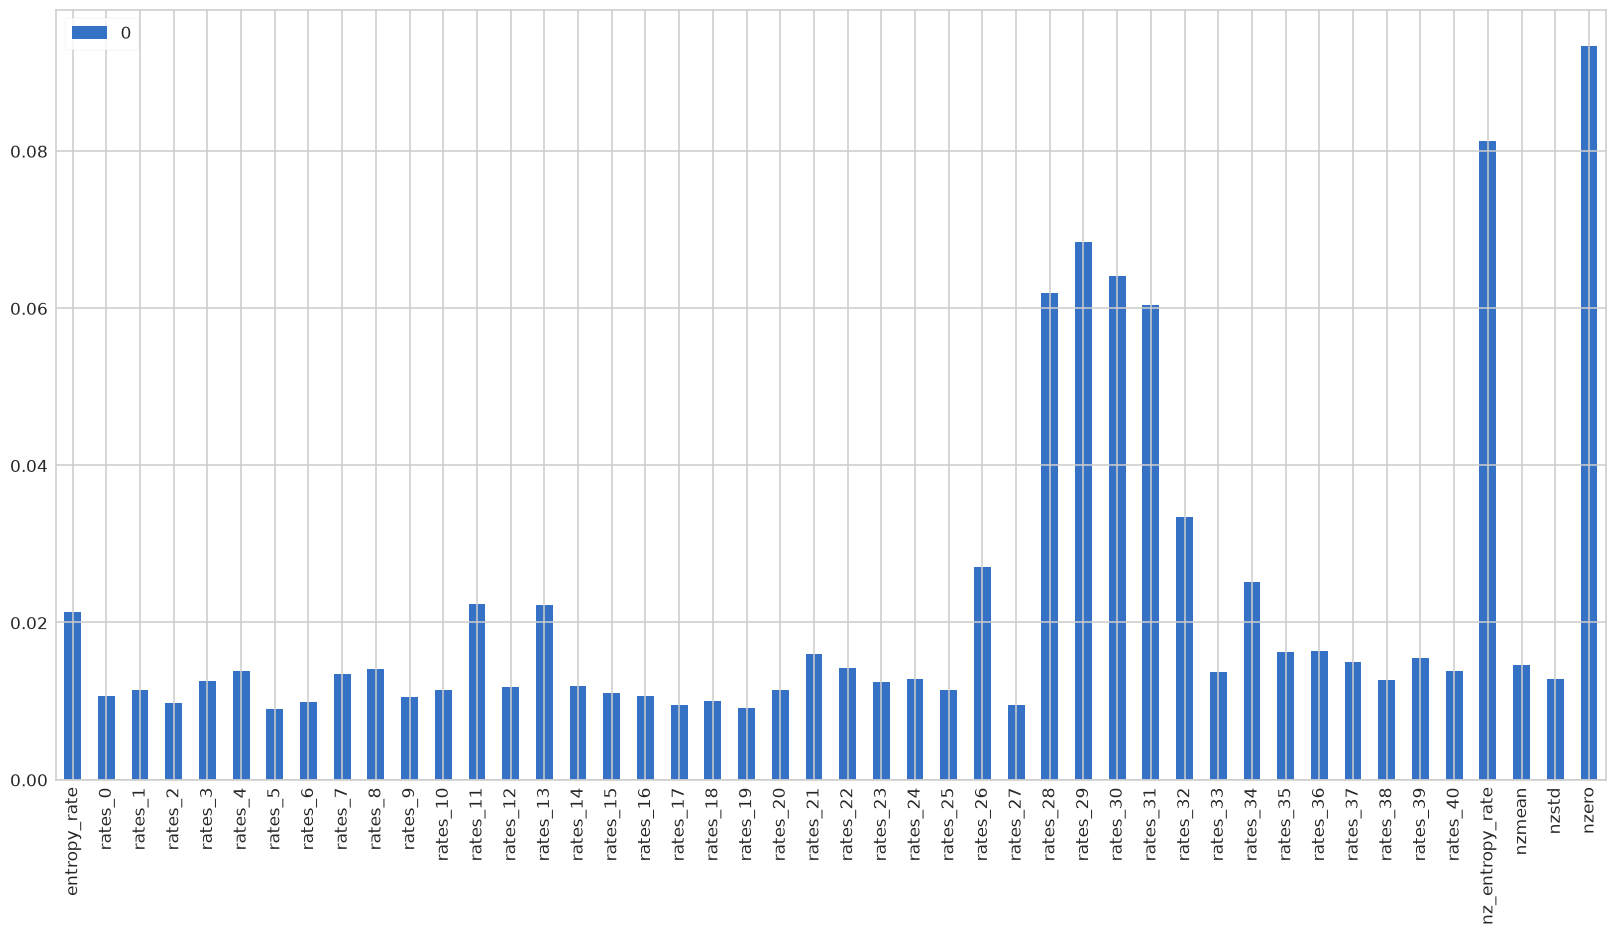

In [26]:
plt.figure(figsize=[20,10])
pd.DataFrame(models[0].feature_importances_,[x for x in df_.columns if x not in ['perplexity','percentage', 'label']]).plot(ax=plt.gca(),kind='bar')


In [27]:
modeldf_=[pd.DataFrame(ROC[model_]) for model_ in modelnames]
ztc=zedstat.processRoc(df=modeldf_[-1],
           order=3, 
           total_samples=len(y_test),
           positive_samples=y_test.sum(),
           alpha=0.01,
           prevalence=.5)

ztc.smooth(STEP=0.001)
ztc.allmeasures(interpolate=True)
ztc.usample(precision=2)
ztc.getBounds()

auc_c=np.array(ztc.auc(alpha=.05))*100
deltac=(auc_c[1]-auc_c[2])/2
lc=str(auc_c[0])[:4]+'%'
ztc.auc(alpha=.05)

(0.9825394578354396,
 np.float64(0.9877537426368536),
 np.float64(0.9773251730340257))

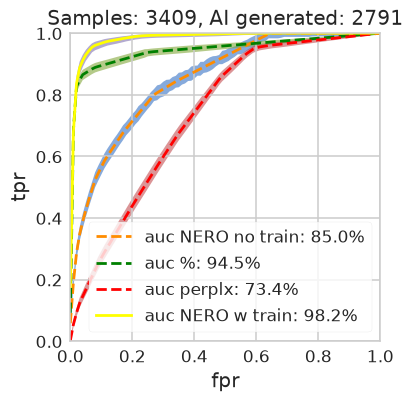

In [28]:
plt.figure(figsize=(4,4))
ax=plt.gca()
ax=zte.get().tpr.plot(style='--',ax=ax,color='darkorange',lw=2)
ax=ztpc.get().tpr.plot(style='--',ax=ax,color='green',lw=2)
ax=ztpx.get().tpr.plot(style='--',ax=ax,color='red',lw=2)
ax=ztc.get().tpr.plot(style='-',ax=ax,color='yellow',lw=2)

plt.fill_between(x=zte.get().index, y1=zte.df_lim['U'].tpr,y2=zte.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpc.get().index, y1=ztpc.df_lim['U'].tpr,y2=ztpc.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztpx.get().index, y1=ztpx.df_lim['U'].tpr,y2=ztpx.df_lim['L'].tpr, alpha=.6)
plt.fill_between(x=ztc.get().index, y1=ztc.df_lim['U'].tpr,y2=ztc.df_lim['L'].tpr, alpha=.6)


dx=pd.DataFrame({'tpr_upper':zte.df_lim['U'].tpr,'tpr_lower':zte.df_lim['L'].tpr}).join(zte.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_notraining.csv')
dx=pd.DataFrame({'tpr_upper':ztpc.df_lim['U'].tpr,'tpr_lower':ztpc.df_lim['L'].tpr}).join(ztpc.get()['tpr'])
dx.to_csv('percentage_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztpx.df_lim['U'].tpr,'tpr_lower':ztpx.df_lim['L'].tpr}).join(ztpx.get()['tpr'])
dx.to_csv('perplexity_'+SUBSET+'.csv')
dx=pd.DataFrame({'tpr_upper':ztc.df_lim['U'].tpr,'tpr_lower':ztc.df_lim['L'].tpr}).join(ztc.get()['tpr'])
dx.to_csv('nero_'+SUBSET+'_trained.csv')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.legend(['auc NERO no train: '+le,'auc %: '+lpc,'auc perplx: '+lpx, 'auc NERO w train: '+lc],loc='lower right')
ax.set_title('Samples: '+str(len(ytrue))+', AI generated: '+str(int(ytrue.sum())))
ax.set_ylabel('tpr');
plt.savefig('roc-notraining'+SUBSET+'.pdf',bbox_inches='tight',transparent=True)